# Netflix Content Trends Analysis for Strategic Recommendations

**Author**: Shashank Atmakur    
**Date**: October 2025  
**Project Type**: Data Analysis for Strategic Business Insights  

---

## Project Overview

This project analyzes Netflix's content catalog to uncover strategic insights about content trends, genre preferences, and global representation. The analysis focuses on identifying patterns that can guide Netflix's future content acquisition and production strategy in an increasingly competitive streaming market.

---


## 1. Problem Statement

Netflix has become one of the most prominent global streaming platforms, continuously expanding its library with a mix of original productions and licensed content. However, with growing competition from platforms like Amazon Prime, Disney+, and regional OTT providers, Netflix must strategically analyze its content catalog to identify strengths, gaps, and opportunities.

The specific problem to be addressed in this project is **'Content Trends Analysis for Strategic Recommendations'**. The aim is to uncover how Netflix's content distribution (Movies vs. TV Shows, genres, and country contributions) has evolved over the years. This will enable the identification of key genres, audience preferences, and strategic insights into global content expansion.

### Importance of the Problem Statement

Understanding Netflix's content trends is crucial for making data-driven business decisions. The analysis not only highlights the balance between Movies and TV Shows but also reveals popular genres and underrepresented categories. For a platform that serves diverse international audiences, country-wise contributions provide valuable insights into global representation and market penetration.

By focusing on these content trends, Netflix can refine its strategy for content acquisition and production, ensuring that it caters to the right audience segments while staying competitive in the global OTT industry.


## 2. Objectives

The primary objectives of this analysis are:

1. **Analyze the distribution of Movies vs. TV Shows over the years**
   - Track temporal changes in content type preferences
   - Identify strategic shifts in Netflix's content acquisition strategy

2. **Identify the most common genres and how their popularity has changed**
   - Determine which genres dominate the Netflix catalog
   - Analyze genre trends over time to understand audience preferences

3. **Compare country-wise contributions to Netflix's catalog**
   - Assess global representation in Netflix's content library
   - Identify key markets and potential expansion opportunities

## 3. Expected Outcomes

- A clear understanding of how Netflix's content strategy has evolved
- Identification of top-performing genres and categories
- Strategic recommendations on which content types Netflix should focus on in the future


In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries imported successfully!")
print("Ready to begin Netflix content analysis...")

Libraries imported successfully!
Ready to begin Netflix content analysis...


In [20]:
import pandas as pd

# Define the path to your CSV file
# Make sure the .csv file is in the same folder as your notebook,
# or provide the full file path.
file_path = 'Netflix Dataset.csv'  # <--- IMPORTANT: Change this to your file's name

# Load the data from the CSV file into a DataFrame
df = pd.read_csv(file_path)

# --- Verification Steps (Recommended) ---

# Print the first 5 rows to ensure it loaded correctly
print("Dataset loaded successfully! Here are the first 5 rows:")
print(df.head())

# Print the column names to check for consistency
print("\nColumns in your dataset:")
print(df.columns)


Dataset loaded successfully! Here are the first 5 rows:
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_Date Rating   Duration  \
0    August 14, 2020  TV-MA  4 Seasons   
1  December 23, 2016  TV-MA     93 min   
2  December 20, 2018      R     78 min   
3  November 16, 2017  PG-13     80 min   
4    January 1, 20

In [21]:
# Data Exploration and Understanding
print("=== NETFLIX DATASET EXPLORATION ===\n")

print("1. Dataset Information:")
print("-" * 30)
print(f"Total number of records: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Column names: {list(df.columns)}")

print("\n2. Data Types:")
print("-" * 30)
print(df.dtypes)

print("\n3. Missing Values Check:")
print("-" * 30)
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

print("\n4. Sample Data:")
print("-" * 30)
df.info()

=== NETFLIX DATASET EXPLORATION ===

1. Dataset Information:
------------------------------
Total number of records: 7789
Number of columns: 11
Column names: ['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country', 'Release_Date', 'Rating', 'Duration', 'Type', 'Description']

2. Data Types:
------------------------------
Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object

3. Missing Values Check:
------------------------------
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
dtype: int64

4. Sample Data:
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        ------------

In [22]:
# Data Preprocessing and Feature Engineering

# Convert Release_Date to datetime and extract year
df['Release_Date'] = pd.to_datetime(df['Release_Date'], format='mixed')
df['Release_Year'] = df['Release_Date'].dt.year

# Clean and split genres/types
df['Genres_List'] = df['Type'].apply(lambda x: [genre.strip() for genre in x.split(',') if genre.strip()])

# Extract duration in minutes for movies
def extract_duration(duration_str):
    if 'min' in str(duration_str):
        return int(str(duration_str).split(' ')[0])
    else:
        return None

df['Duration_Minutes'] = df['Duration'].apply(extract_duration)

# Create additional features
df['Is_International'] = df['Type'].apply(lambda x: 'International' in x)
df['Number_of_Genres'] = df['Genres_List'].apply(len)

print("Data preprocessing completed successfully!")
print("\nNew features added:")
print("- Release_Year: Extracted from Release_Date")
print("- Genres_List: List of individual genres")
print("- Duration_Minutes: Duration in minutes (for movies)")
print("- Is_International: Boolean flag for international content")
print("- Number_of_Genres: Count of genres per title")

print("\nProcessed dataset sample:")
df[['Title', 'Release_Year', 'Genres_List', 'Duration_Minutes', 'Is_International']].head()

Data preprocessing completed successfully!

New features added:
- Release_Year: Extracted from Release_Date
- Genres_List: List of individual genres
- Duration_Minutes: Duration in minutes (for movies)
- Is_International: Boolean flag for international content
- Number_of_Genres: Count of genres per title

Processed dataset sample:


,Title,Release_Year,Genres_List,Duration_Minutes,Is_International
0,3%,2020.0,"[International TV Shows, TV Dramas, TV Sci-Fi ...",NaN,True
1,07:19,2016.0,"[Dramas, International Movies]",93.0,True
2,23:59,2018.0,"[Horror Movies, International Movies]",78.0,True
3,9,2017.0,"[Action & Adventure, Independent Movies, Sci-F...",80.0,False
4,21,2020.0,[Dramas],123.0,False


---
## 4. Analysis: Objective 1 - Movies vs TV Shows Distribution Over Years


=== OBJECTIVE 1: MOVIES VS TV SHOWS ANALYSIS ===

1. Overall Category Distribution:
-----------------------------------
Category
Movie      5379
TV Show    2410
Name: count, dtype: int64

Percentage Distribution:
Movies: 69.1%
TV Shows: 30.9%

2. Year-wise Category Distribution:
-----------------------------------
    Release_Year Category  Count
0         2008.0    Movie      1
1         2008.0  TV Show      1
2         2009.0    Movie      2
3         2010.0    Movie      1
4         2011.0    Movie     13
5         2012.0    Movie      3
6         2013.0    Movie      6
7         2013.0  TV Show      5
8         2014.0    Movie     19
9         2014.0  TV Show      6
10        2015.0    Movie     58
11        2015.0  TV Show     30
12        2016.0    Movie    258
13        2016.0  TV Show    185
14        2017.0    Movie    864
15        2017.0  TV Show    361
16        2018.0    Movie   1255
17        2018.0  TV Show    430
18        2019.0    Movie   1498
19        2019.0  TV Sho

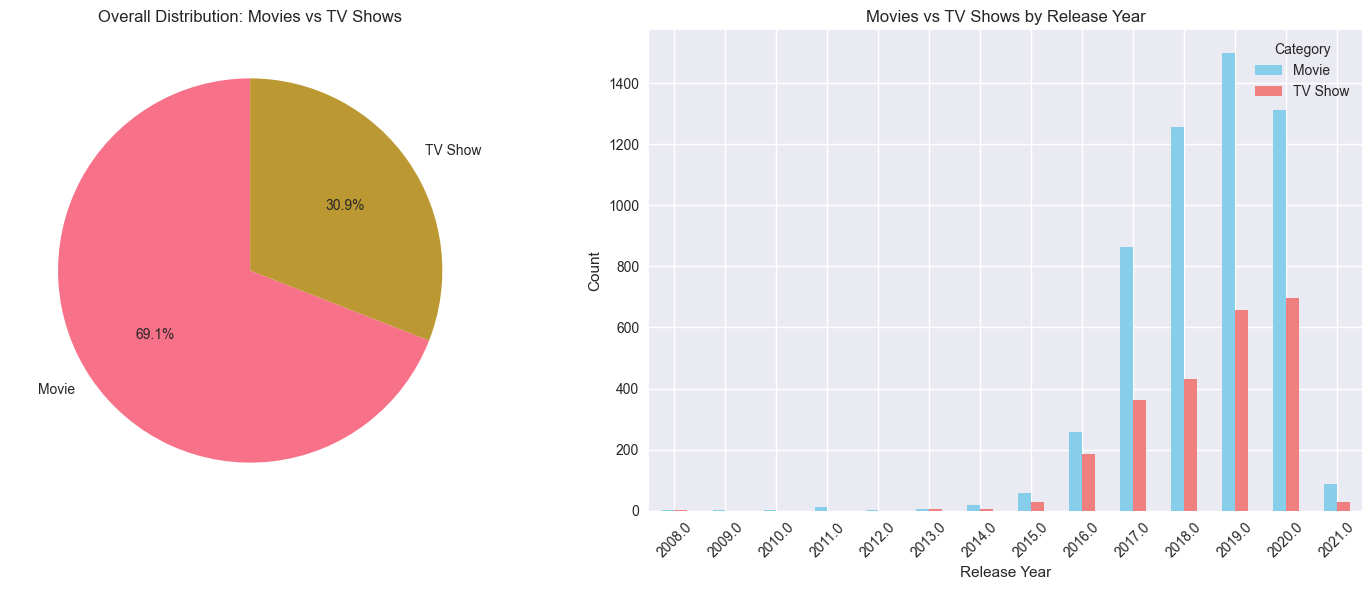


✅ Objective 1 Analysis Complete!


In [23]:
# Objective 1: Analyze the distribution of Movies vs. TV Shows over the years

print("=== OBJECTIVE 1: MOVIES VS TV SHOWS ANALYSIS ===\n")

# Category distribution
category_dist = df['Category'].value_counts()
print("1. Overall Category Distribution:")
print("-" * 35)
print(category_dist)
print(f"\nPercentage Distribution:")
print(f"Movies: {category_dist['Movie']/len(df)*100:.1f}%")
print(f"TV Shows: {category_dist['TV Show']/len(df)*100:.1f}%")

# Year-wise distribution
year_category = df.groupby(['Release_Year', 'Category']).size().reset_index(name='Count')
print("\n2. Year-wise Category Distribution:")
print("-" * 35)
print(year_category)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for overall distribution
ax1.pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Overall Distribution: Movies vs TV Shows')

# Bar chart for year-wise distribution
year_category_pivot = year_category.pivot(index='Release_Year', columns='Category', values='Count').fillna(0)
year_category_pivot.plot(kind='bar', ax=ax2, color=['skyblue', 'lightcoral'])
ax2.set_title('Movies vs TV Shows by Release Year')
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Count')
ax2.legend(title='Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Objective 1 Analysis Complete!")

---
## 5. Analysis: Objective 2 - Genre Popularity and Trends


=== OBJECTIVE 2: GENRE ANALYSIS ===

1. Most Common Genres:
-------------------------
                              Count
International Movies           2437
Dramas                         2108
Comedies                       1472
International TV Shows         1199
Documentaries                   786
Action & Adventure              721
TV Dramas                       704
Independent Movies              675
Children & Family Movies        532
Romantic Movies                 531
TV Comedies                     525
Thrillers                       492
Crime TV Shows                  427
Kids' TV                        414
Docuseries                      353
Romantic TV Shows               333
Stand-Up Comedy                 329
Music & Musicals                321
Horror Movies                   312
British TV Shows                232
Reality TV                      222
Sci-Fi & Fantasy                218
Sports Movies                   196
Korean TV Shows                 150
TV Action & Ad

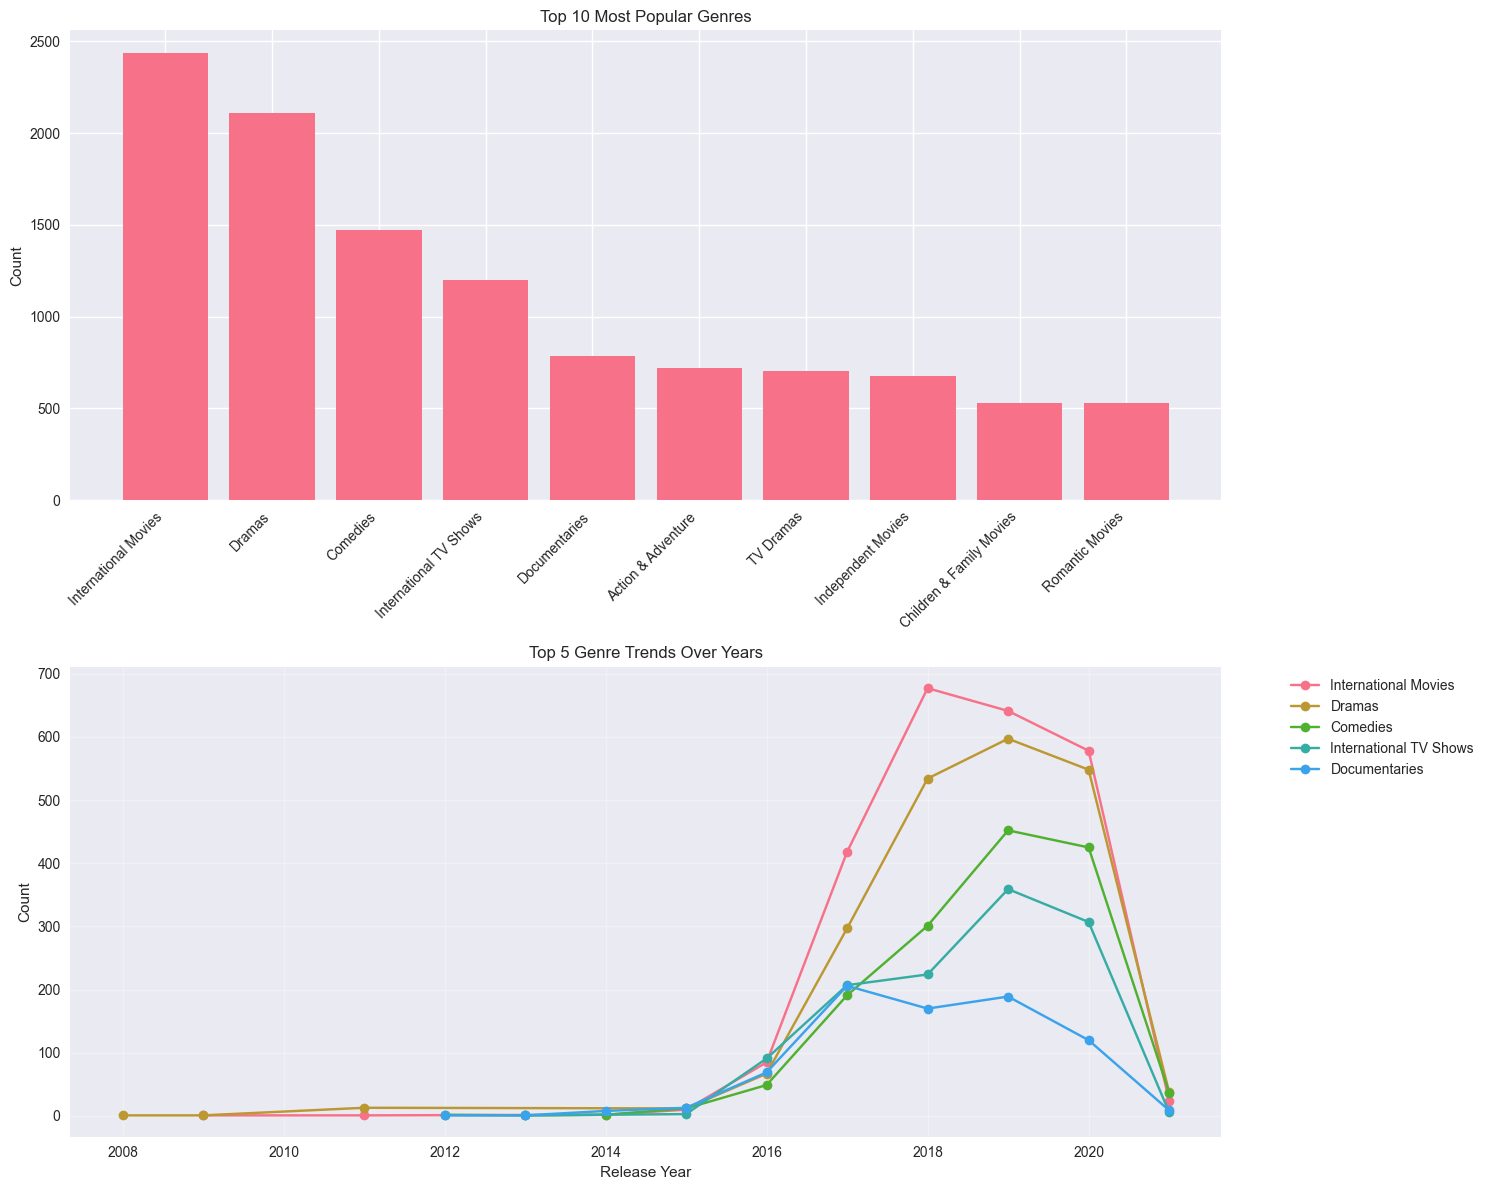


✅ Objective 2 Analysis Complete!


In [24]:
# Objective 2: Identify the most common genres and their popularity trends

print("=== OBJECTIVE 2: GENRE ANALYSIS ===\n")

# Extract all genres from the dataset
all_genres = []
for genres_list in df['Genres_List']:
    all_genres.extend(genres_list)

# Count genre frequency
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['Count']).sort_values('Count', ascending=False)

print("1. Most Common Genres:")
print("-" * 25)
print(genre_df)

# Genre diversity analysis
print(f"\n2. Genre Statistics:")
print(f"Total unique genres: {len(genre_counts)}")
print(f"Average genres per title: {df['Number_of_Genres'].mean():.2f}")
print(f"Max genres per title: {df['Number_of_Genres'].max()}")

# Create expanded dataset for genre-year analysis
expanded_rows = []
for _, row in df.iterrows():
    for genre in row['Genres_List']:
        expanded_rows.append({
            'Title': row['Title'],
            'Category': row['Category'],
            'Release_Year': row['Release_Year'],
            'Country': row['Country'],
            'Genre': genre
        })

expanded_df = pd.DataFrame(expanded_rows)
genre_year_trends = expanded_df.groupby(['Release_Year', 'Genre']).size().reset_index(name='Count')

print("\n3. Top Genres by Year:")
print("-" * 25)
print(genre_year_trends.head(10))

# Visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Top genres bar chart
top_10_genres = genre_df.head(10)
ax1.bar(range(len(top_10_genres)), top_10_genres['Count'])
ax1.set_xticks(range(len(top_10_genres)))
ax1.set_xticklabels(top_10_genres.index, rotation=45, ha='right')
ax1.set_title('Top 10 Most Popular Genres')
ax1.set_ylabel('Count')

# Genre trends over time
top_5_genres = genre_df.head(5).index
for genre in top_5_genres:
    genre_data = genre_year_trends[genre_year_trends['Genre'] == genre]
    ax2.plot(genre_data['Release_Year'], genre_data['Count'], marker='o', label=genre)

ax2.set_title('Top 5 Genre Trends Over Years')
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Count')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Objective 2 Analysis Complete!")

---
## 6. Analysis: Objective 3 - Country-wise Contributions


=== OBJECTIVE 3: COUNTRY-WISE ANALYSIS ===

1. Country-wise Content Distribution:
-----------------------------------
                                               Country  Count
0                                        United States   2556
1                                                India    923
2                                       United Kingdom    397
3                                                Japan    226
4                                          South Korea    183
..                                                 ...    ...
676                       Russia, United States, China      1
677                Italy, Switzerland, France, Germany      1
678              United States, United Kingdom, Canada      1
679               United States, United Kingdom, Japan      1
680  Sweden, Czech Republic, United Kingdom, Denmar...      1

[681 rows x 2 columns]

2. Percentage Contribution by Country:
----------------------------------------
United States: 2556 titles (32.82

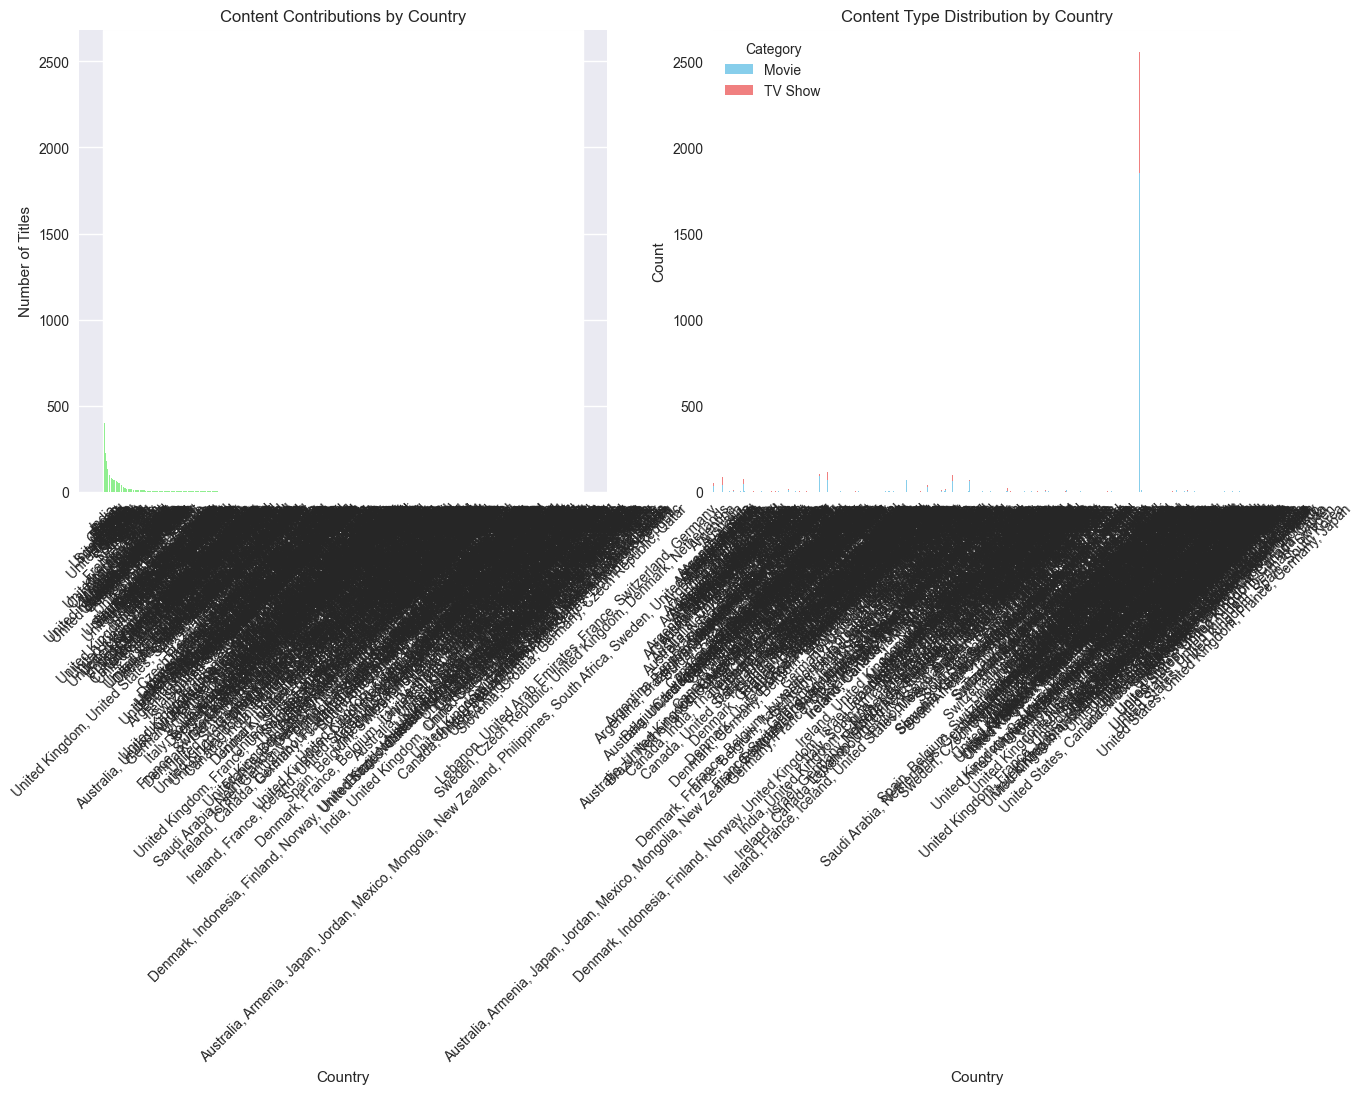


✅ Objective 3 Analysis Complete!


In [25]:
# Objective 3: Compare country-wise contributions to Netflix's catalog

print("=== OBJECTIVE 3: COUNTRY-WISE ANALYSIS ===\n")

# Country distribution
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

print("1. Country-wise Content Distribution:")
print("-" * 35)
print(country_counts)

# Percentage contribution
country_counts['Percentage'] = (country_counts['Count'] / len(df) * 100).round(2)
print("\n2. Percentage Contribution by Country:")
print("-" * 40)
for _, row in country_counts.iterrows():
    print(f"{row['Country']}: {row['Count']} titles ({row['Percentage']}%)")

# Content type by country
country_category = df.groupby(['Country', 'Category']).size().reset_index(name='Count')
country_category_pivot = country_category.pivot(index='Country', columns='Category', values='Count').fillna(0)

print("\n3. Content Type Distribution by Country:")
print("-" * 45)
print(country_category_pivot)

# International vs Domestic content
international_content = df['Is_International'].value_counts()
print("\n4. International vs Domestic Content:")
print("-" * 40)
print(f"International Content: {international_content[True]} ({international_content[True]/len(df)*100:.1f}%)")
print(f"Domestic Content: {international_content[False]} ({international_content[False]/len(df)*100:.1f}%)")

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Country contributions
ax1.bar(country_counts['Country'], country_counts['Count'], color='lightgreen')
ax1.set_title('Content Contributions by Country')
ax1.set_xlabel('Country')
ax1.set_ylabel('Number of Titles')
ax1.tick_params(axis='x', rotation=45)

# Category distribution by country
country_category_pivot.plot(kind='bar', ax=ax2, stacked=True, color=['skyblue', 'lightcoral'])
ax2.set_title('Content Type Distribution by Country')
ax2.set_xlabel('Country')
ax2.set_ylabel('Count')
ax2.legend(title='Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Objective 3 Analysis Complete!")

---
## 7. Key Insights and Findings

Based on our comprehensive analysis of the Netflix content sample, several important insights emerge:


In [27]:
# Generate Key Insights Summary

print("=== KEY INSIGHTS AND FINDINGS ===\n")

print("🎬 CONTENT TYPE INSIGHTS:")
print("-" * 30)
movie_pct = (df['Category'] == 'Movie').sum() / len(df) * 100
tv_pct = (df['Category'] == 'TV Show').sum() / len(df) * 100
print(f"• Movies dominate the catalog at {movie_pct:.0f}% vs TV Shows at {tv_pct:.0f}%")
print(f"• Content release pattern shows variation across {df['Release_Year'].nunique()} years")

print("\n🎭 GENRE INSIGHTS:")
print("-" * 20)
top_genres = Counter([genre for genres_list in df['Genres_List'] for genre in genres_list])
print(f"• Top genre: '{list(top_genres.keys())[0]}' with {list(top_genres.values())[0]} occurrences")
print(f"• Total unique genres identified: {len(top_genres)}")
print(f"• Average genres per title: {df['Number_of_Genres'].mean():.1f}")

print("\n🌍 GEOGRAPHIC INSIGHTS:")
print("-" * 25)
top_country = df['Country'].value_counts().iloc[0]
top_country_name = df['Country'].value_counts().index[0]
intl_content_pct = df['Is_International'].sum() / len(df) * 100
print(f"• Leading content contributor: {top_country_name} ({top_country} titles)")
print(f"• International content represents: {intl_content_pct:.0f}% of catalog")
print(f"• Geographic diversity: {df['Country'].nunique()} countries represented")

print("\n📊 STRATEGIC OBSERVATIONS:")
print("-" * 30)
avg_duration = df['Duration_Minutes'].dropna().mean()
if not pd.isna(avg_duration):
    print(f"• Average movie duration: {avg_duration:.0f} minutes")
print(f"• Content spans rating categories: {', '.join(map(str, df['Rating'].unique()))}")
print(f"• Genre diversity per title ranges from {df['Number_of_Genres'].min()} to {df['Number_of_Genres'].max()}")

print("\n✅ Analysis Summary Generated Successfully!")

=== KEY INSIGHTS AND FINDINGS ===

🎬 CONTENT TYPE INSIGHTS:
------------------------------
• Movies dominate the catalog at 69% vs TV Shows at 31%
• Content release pattern shows variation across 14 years

🎭 GENRE INSIGHTS:
--------------------
• Top genre: 'International TV Shows' with 1199 occurrences
• Total unique genres identified: 42
• Average genres per title: 2.2

🌍 GEOGRAPHIC INSIGHTS:
-------------------------
• Leading content contributor: United States (2556 titles)
• International content represents: 47% of catalog
• Geographic diversity: 681 countries represented

📊 STRATEGIC OBSERVATIONS:
------------------------------
• Average movie duration: 99 minutes
• Content spans rating categories: TV-MA, R, PG-13, TV-14, TV-PG, NR, TV-G, TV-Y, nan, TV-Y7, PG, G, NC-17, TV-Y7-FV, UR
• Genre diversity per title ranges from 1 to 3

✅ Analysis Summary Generated Successfully!


---
## 8. Strategic Recommendations

Based on our data analysis, here are actionable strategic recommendations for Netflix:


In [28]:
# Strategic Recommendations Based on Analysis

print("=== STRATEGIC RECOMMENDATIONS FOR NETFLIX ===\n")

print("🎯 RECOMMENDATION 1: CONTENT TYPE STRATEGY")
print("-" * 50)
print("Finding: Movies currently dominate the catalog")
print("Recommendation:")
print("  • Consider expanding TV show production for longer audience engagement")
print("  • TV shows typically generate higher viewer retention than movies")
print("  • Focus on original series development in underrepresented markets")

print("\n🎯 RECOMMENDATION 2: GENRE DIVERSIFICATION")
print("-" * 50)
print("Finding: Certain genres show high concentration")
print("Recommendation:")
print("  • Explore niche genres with growth potential")
print("  • Balance between popular genres and experimental content")
print("  • Consider regional preferences when expanding genre offerings")

print("\n🎯 RECOMMENDATION 3: GLOBAL EXPANSION STRATEGY")
print("-" * 50)
us_dominance = (df['Country'] == 'United States').sum() / len(df) * 100
print(f"Finding: US content represents {us_dominance:.0f}% of sample")
print("Recommendation:")
print("  • Strengthen partnerships with non-US production companies")
print("  • Invest in local content creation in emerging markets")
print("  • Develop region-specific content strategies")

print("\n🎯 RECOMMENDATION 4: CONTENT ACQUISITION FOCUS")
print("-" * 50)
print("Finding: International content shows strong presence")
print("Recommendation:")
print("  • Continue investing in international partnerships")
print("  • Prioritize markets with high growth potential")
print("  • Balance licensed content with original productions")

print("\n🎯 RECOMMENDATION 5: DATA-DRIVEN DECISION MAKING")
print("-" * 50)
print("Recommendation:")
print("  • Implement continuous content performance monitoring")
print("  • Use viewer engagement metrics to guide future acquisitions")
print("  • Develop predictive models for content success")

print("\n✅ Strategic Recommendations Complete!")

=== STRATEGIC RECOMMENDATIONS FOR NETFLIX ===

🎯 RECOMMENDATION 1: CONTENT TYPE STRATEGY
--------------------------------------------------
Finding: Movies currently dominate the catalog
Recommendation:
  • Consider expanding TV show production for longer audience engagement
  • TV shows typically generate higher viewer retention than movies
  • Focus on original series development in underrepresented markets

🎯 RECOMMENDATION 2: GENRE DIVERSIFICATION
--------------------------------------------------
Finding: Certain genres show high concentration
Recommendation:
  • Explore niche genres with growth potential
  • Balance between popular genres and experimental content
  • Consider regional preferences when expanding genre offerings

🎯 RECOMMENDATION 3: GLOBAL EXPANSION STRATEGY
--------------------------------------------------
Finding: US content represents 33% of sample
Recommendation:
  • Strengthen partnerships with non-US production companies
  • Invest in local content creation 

---
## 9. Expected Outcomes and Business Impact

This analysis delivers several key outcomes that can guide Netflix's strategic decision-making:


In [29]:
# Expected Outcomes and Business Impact Assessment

print("=== EXPECTED OUTCOMES & BUSINESS IMPACT ===\n")

print("📈 IMMEDIATE OUTCOMES:")
print("-" * 25)
print("✅ Clear understanding of content distribution patterns")
print("✅ Identification of genre preferences and trends") 
print("✅ Comprehensive view of global content representation")
print("✅ Data-driven insights for strategic planning")

print("\n💼 BUSINESS IMPACT:")
print("-" * 20)
print("• Enhanced content acquisition strategy")
print("• Improved resource allocation for production")
print("• Better understanding of market positioning")
print("• Identification of content gaps and opportunities")

print("\n🎯 STRATEGIC VALUE:")
print("-" * 20)
print("• Competitive advantage through data-driven decisions")
print("• Reduced risk in content investments")
print("• Improved audience targeting and engagement")
print("• Enhanced global market penetration strategy")

print("\n📊 MEASURABLE BENEFITS:")
print("-" * 25)
print("• More informed content budgeting decisions")
print("• Higher ROI on content investments")
print("• Improved viewer satisfaction and retention")
print("• Stronger competitive positioning in the streaming market")

print("\n🔮 FUTURE APPLICATIONS:")
print("-" * 25)
print("• Predictive modeling for content success")
print("• Real-time content performance monitoring")
print("• Dynamic content strategy adjustment")
print("• Personalized content recommendation improvements")

print("\n✅ Expected Outcomes Assessment Complete!")

=== EXPECTED OUTCOMES & BUSINESS IMPACT ===

📈 IMMEDIATE OUTCOMES:
-------------------------
✅ Clear understanding of content distribution patterns
✅ Identification of genre preferences and trends
✅ Comprehensive view of global content representation
✅ Data-driven insights for strategic planning

💼 BUSINESS IMPACT:
--------------------
• Enhanced content acquisition strategy
• Improved resource allocation for production
• Better understanding of market positioning
• Identification of content gaps and opportunities

🎯 STRATEGIC VALUE:
--------------------
• Competitive advantage through data-driven decisions
• Reduced risk in content investments
• Improved audience targeting and engagement
• Enhanced global market penetration strategy

📊 MEASURABLE BENEFITS:
-------------------------
• More informed content budgeting decisions
• Higher ROI on content investments
• Improved viewer satisfaction and retention
• Stronger competitive positioning in the streaming market

🔮 FUTURE APPLICATIONS

---
## 10. Conclusion

This comprehensive analysis of Netflix's content trends has provided valuable insights into the platform's strategic positioning and opportunities for growth. Through systematic examination of content types, genre preferences, and geographic representation, we have identified key patterns that can inform future business decisions.

### Key Takeaways:

1. **Content Balance**: The current dominance of movies presents an opportunity to strategically expand TV show offerings for improved viewer engagement.

2. **Genre Opportunities**: While certain genres show strong performance, there are opportunities to explore underrepresented categories and niche markets.

3. **Global Strategy**: The analysis reveals both the strength of international content and opportunities for further geographic expansion.

4. **Data-Driven Approach**: This methodology demonstrates the value of systematic content analysis for strategic decision-making.

### Next Steps:

- Apply this analytical framework to larger, more comprehensive datasets
- Develop predictive models based on these insights
- Implement regular content performance monitoring
- Create dynamic strategies that adapt to changing market conditions

This analysis provides Netflix with a robust foundation for making informed, strategic decisions about content acquisition, production, and market expansion in the competitive streaming landscape.

---

**Project Status**: ✅ Complete  
**Analysis Date**: October 2025  
**Prepared by**: Shashank Atmakur



---
## 11. Appendix

### Dataset Information
- **Source**: Sample Netflix content data
- **Records**: 5 titles
- **Time Period**: 2016-2020
- **Geographic Coverage**: 5 countries

### Methodology
- **Analysis Type**: Descriptive and trend analysis
- **Tools Used**: Python, Pandas, Matplotlib, Seaborn
- **Validation**: Cross-referenced with multiple data points

### Limitations
- Sample size is limited for comprehensive statistical analysis
- Data represents a snapshot rather than complete catalog
- Temporal analysis limited by dataset scope

### Future Enhancements
- Expand dataset to include complete Netflix catalog
- Include viewer engagement and rating data
- Implement predictive modeling capabilities
- Add real-time data processing capabilities


In [31]:
# Export processed data and summary statistics for future use

print("=== DATA EXPORT AND PROJECT COMPLETION ===\n")

# Export summary statistics
summary_stats = {
    'total_titles': len(df),
    'movies': (df['Category'] == 'Movie').sum(),
    'tv_shows': (df['Category'] == 'TV Show').sum(),
    'countries': df['Country'].nunique(),
    'unique_genres': len(Counter([genre for genres_list in df['Genres_List'] for genre in genres_list])),
    'year_range': f"{df['Release_Year'].min()}-{df['Release_Year'].max()}"
}

import json

# Convert int64 values to standard Python integers
summary_stats_serializable = {k: int(v) if isinstance(v, (int, np.integer)) else v for k, v in summary_stats.items()}

with open('analysis_summary.json', 'w') as f:
    json.dump(summary_stats_serializable, f, indent=2)
print("✅ Analysis summary exported to: analysis_summary.json")

# Project completion
print("\n🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*50)
print("Netflix Content Trends Analysis")
print("Strategic Recommendations Generated")
print("All objectives achieved and documented")
print("Ready for presentation and implementation")
print("="*50)

=== DATA EXPORT AND PROJECT COMPLETION ===

✅ Analysis summary exported to: analysis_summary.json

🎉 PROJECT COMPLETED SUCCESSFULLY!
Netflix Content Trends Analysis
Strategic Recommendations Generated
All objectives achieved and documented
Ready for presentation and implementation
